$\textbf{Problem}$: Apply the PRAC-DTDT-ID workflow to a (vanilla) $\textit{autoencoder}$.

$\textbf{Solution}$: 
* Problem: to learn a lower-dimensional latent manifold representation of the input manifold (this is justified by the $\textit{submanifold hypothesis}$, namely that the data-generating distribution $p(\mathbf x)$ is essentially supported only for $\mathbf x\in \mathbf R^{<d}$ in some lower-dimensional submanifold $\mathbf R^{<d}$ of the input manifold $\cong\mathbf R^d$).
* Representation: assume the abstract data manifold has already been coordinatized via some atlas of charts into feature vectors $\mathbf x\in\mathbf R^d$.
* Architecture: an encoder neural network $\mathbf e_{\boldsymbol{\phi}}:\mathbf R^d\to\mathbf R^{<d}$ that maps input feature vectors $\mathbf x\in\mathbf R^d$ to a lower-dimensional latent manifold $\mathbf e_{\boldsymbol{\phi}}(\mathbf x)\in\mathbf R^{<d}$. This is then passed through a decoder neural network $\mathbf d_{\boldsymbol{\theta}}:\mathbf R^{<d}\to\mathbf R^d$ that attempts to reconstruct the original input feature vector $\mathbf d_{\boldsymbol{\theta}}(\mathbf e_{\boldsymbol{\phi}}(\mathbf x))\approx\mathbf x\in\mathbf R^d$ from its encoded latent manifold representation $\mathbf e_{\boldsymbol{\phi}}(\mathbf x)\in\mathbf R^{<d}$. In this context, the latent manifold $\mathbf R^{<d}$ is also called the $\textit{bottleneck}$ as it's the narrowest pinch point (a hidden layer of $<d$ neurons) in the autoencoder. If it were not $<d$ but rather $\geq d$, then the autoencoder could just memorize the input data without learning the relevant submanifold structure, so by forcing the information to flow through a bottleneck (a deliberately lossy form of compression), the autoencoder has to encode efficiently to survive the bottleneck.
* Cost: since the overall goal of the autoencoder (by virtue of its etymology!) is to essentially implement an identity function $\mathbf x\mapsto\mathbf x$ ("reconstruction of $\mathbf x$"), the reconstruction loss function may taken to be the usual MSE:
$$L(\hat{\mathbf x},\mathbf x)=\frac{|\hat{\mathbf x}-\mathbf x|^2}{2}$$
so the corresponding cost function is just the expected reconstruction loss over the empirical approximation of $p(\mathbf x)$ due to $N$ i.i.d. samples $\mathbf x_1,...,\mathbf x_N\in\mathbf R^d$ from $p(\mathbf x)$:
$$C(\boldsymbol{\theta},\boldsymbol{\phi})=\frac{1}{N}\sum_{i=1}^NL(\mathbf d_{\boldsymbol{\theta}}(\mathbf e_{\boldsymbol{\phi}}(\mathbf x_i)),\mathbf x_i)$$
* Data: one of the advantages of autoencoders is that it is a data-agnostic framework which is thus completely general and can be applied to learn more compact representations of essentially any kind of data (e.g. images, text, audio, ...).
* Train: use the Adam optimizer.
* Dev: use to fine-tune hyperparameters like the bottleneck depth $<d$.
* Test: self-explanatory.
* Iterate: self-explanatory.
* Deploy: self-explanatory.


$\textbf{Problem}$: Having fleshed out the theory of autoencoders, implement a vanilla autoencoder in PyTorch to learn a $16$-dimensional latent manifold representation of the MNIST dataset (where each $28\times 28$ image is flattened and normalized into a feature vector $\mathbf x\in\mathbf [0,1]^{784}$).

$\textbf{Solution}$:

In [ ]:
import torch
import torch.nn as nn

class VanillaAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(in_features=784, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=16),
        )

        self.decoder = nn.Sequential(
            nn.Linear(in_features=16, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=784),
            nn.Sigmoid() # because MNIST pixel intensities will be normalized [0, 1]
        )    

    def forward(self, x):
        # x is a batch of grayscale images with shape (batch_size, 1, 28, 28)
        batch_size = x.shape[0]
        x = x.reshape(batch_size, 784) # or x.reshape(-1, 784)
        z = self.encoder(x)
        x_hat = self.decoder(z)
        x_hat = x_hat.reshape(batch_size, 1, 28, 28)
        return x_hat

In [20]:
from torch.optim import Adam

mnist_autoencoder = VanillaAutoencoder()
loss_func = nn.BCELoss() # rather than MSE b/c MNIST images will have [0, 1] normalized pixel intensities
optimizer = Adam(mnist_autoencoder.parameters(), lr=1e-3)

In [21]:
from datasets import load_dataset
from torchvision import transforms
from torch.utils.data import DataLoader

hf_mnist = load_dataset("mnist")
normalize_tensor = transforms.ToTensor() 

def normalize_batch(batch):
    # Apply the [0, 1] normalization to every image in the current batch
    batch["image"] = [normalize_tensor(img) for img in batch["image"]]
    return batch

hf_mnist.set_transform(normalize_batch)
train_loader = DataLoader(
    dataset=hf_mnist["train"],
    batch_size=64,
    shuffle=True
)
test_loader = DataLoader(
    dataset=hf_mnist["test"],
    batch_size=256,
    shuffle=False
)

num_epochs = 10
C_test = []

for epoch in range(num_epochs):
    mnist_autoencoder.train()
    for batch in train_loader:
        x = batch["image"]

        optimizer.zero_grad()
        x_hat = mnist_autoencoder(x)
        loss = loss_func(x_hat, x)
        loss.backward()
        optimizer.step()

    mnist_autoencoder.eval()
    epoch_loss = 0
    with torch.inference_mode():
        for batch in test_loader:
            x = batch["image"]
            x_hat = mnist_autoencoder(x)
            batch_loss = loss_func(x_hat, x)
            epoch_loss += batch_loss.item()
            
    # Calculate the average loss over all test batches
    avg_loss = epoch_loss / len(test_loader)
    C_test.append(avg_loss)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | Test Loss: {avg_loss:.4f}")

Epoch [1/10] | Test Loss: 0.1403
Epoch [2/10] | Test Loss: 0.1294
Epoch [3/10] | Test Loss: 0.1249
Epoch [4/10] | Test Loss: 0.1220
Epoch [5/10] | Test Loss: 0.1197
Epoch [6/10] | Test Loss: 0.1182
Epoch [7/10] | Test Loss: 0.1170
Epoch [8/10] | Test Loss: 0.1159
Epoch [9/10] | Test Loss: 0.1152
Epoch [10/10] | Test Loss: 0.1145


$\textbf{Problem}$: Following up on the above, seeing the test cost $C_{\text{test}}(\boldsymbol{\phi},\boldsymbol{\theta})$ decreasing as both $\boldsymbol{\phi},\boldsymbol{\theta}$ are being updated by gradient descent is one metric, but another test one can do is to directly inspect the geometry of the latent manifold $[0,\infty)^{16}$. Specifically, define a linear interpolation function that takes $2$ distinct images $\mathbf x\neq\mathbf x'\in [0, 1]^{784}$ and, for $10$ discrete time steps $t=0, 0.1, 0.2,...,1$, returns the corresponding $10$ reconstructed images $\mathbf d_{\boldsymbol{\theta}}((1-t)\mathbf e_{\boldsymbol{\phi}}(\mathbf x)+t\mathbf e_{\boldsymbol{\phi}}(\mathbf x'))\in [0,1]^{784}$.

$\textbf{Solution}$:

In [22]:
def interpolate_latent_manifold(model, x, x_prime, steps=10):
    interpolated_imgs = []
    model.eval()
    with torch.no_grad():
        x = x.reshape(1, 784)
        x_prime = x_prime.reshape(1, 784)
        z = model.encoder(x)
        z_prime = model.encoder(x_prime)
        for t in torch.linspace(0, 1, steps):
            z_t = (1 - t) * z + t * z_prime
            x_hat_t = model.decoder(z_t)
            interpolated_imgs.append(x_hat_t.reshape(1, 1, 28, 28))
    return interpolated_imgs

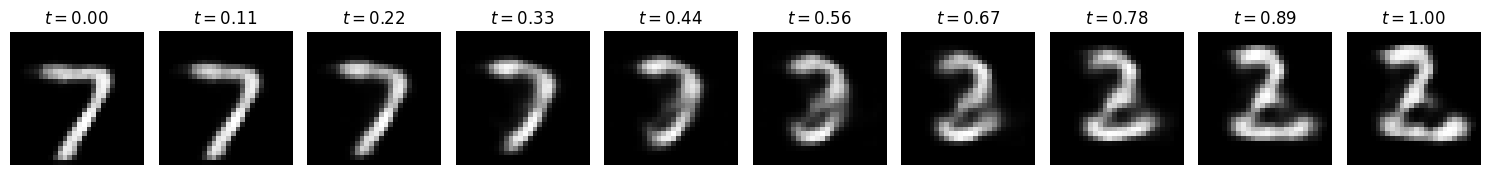

In [24]:
import matplotlib.pyplot as plt

data_iterator = iter(test_loader)
batch = next(data_iterator)
images = batch["image"] 

x = images[0]       
x_prime = images[1]

steps = 10
interpolated_sequence = interpolate_latent_manifold(
    model=mnist_autoencoder, 
    x=x, 
    x_prime=x_prime, 
    steps=steps
)

fig, axes = plt.subplots(nrows=1, ncols=steps, figsize=(15, 3))

for i, img_tensor in enumerate(interpolated_sequence):
    img_array = img_tensor.squeeze().cpu().numpy()
    
    axes[i].imshow(img_array, cmap='gray')
    axes[i].set_title(rf"$t = {i/(steps-1):.2f}$")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

$\textbf{Problem}$: Hence, comment on the key shortcoming of the vanilla autoencoder architecture, and explain how a variational autoencoder architecture addresses this shortcoming.

$\textbf{Solution}$: The shortcoming of the vanilla autoencoder architecture is that the latent manifold representation of the data it learns looks like grouping each of the $10$ digits $0, 1, ..., 9$ into topologically disconnected "islands" in the latent manifold. Thus, forcing the decoder $\mathbf d_{\boldsymbol{\theta}}$ to "swim" between $2$ such islands leads to a blurry interpolation (e.g. the $7$ is gradually turning off as the $2$ is gradually turning on, leading to something that awkwardly almost looks like a $3$). 

Variational autoencoders (VAEs) address this shortcoming of vanilla autoencoders by injecting stochasticity into both the encoder and decoder, transforming them from $\textit{deterministic}$ functions into $\textit{random}$ vectors. 

Instead of a deterministic encoder $\mathbf x\in\mathbf R^d\mapsto\mathbf e_{\boldsymbol{\phi}}(\mathbf x)\in\mathbf R^{<d}$, VAEs use a $\textit{probabilistic}$ encoder composed of $2$ steps:
1. (Deterministic) Map each feature vector $\mathbf x\in\mathbf R^d\mapsto (\langle\mathbf e_{\boldsymbol{\phi}}(\mathbf x)\rangle,\ln\boldsymbol{\sigma}^2_{\boldsymbol{\phi}}(\mathbf x))\in\mathbf R^{2<d}$ to some Gaussian cloud $p_{\boldsymbol{\phi}}(\mathbf e|\mathbf x)=e^{-(\mathbf e-\langle\mathbf e_{\boldsymbol{\phi}}(\mathbf x)\rangle)^T\sigma^{-2}_{\boldsymbol{\phi}}(\mathbf x)(\mathbf e-\langle\mathbf e_{\boldsymbol{\phi}}(\mathbf x)\rangle)/2}/\det(\sqrt{2\pi}\sigma_{\boldsymbol{\phi}}(\mathbf x))$ in the latent manifold (diagonal covariance matrix $\sigma^2_{\boldsymbol{\phi}}(\mathbf x)=\text{diag}(\boldsymbol{\sigma}^2_{\boldsymbol{\phi}}(\mathbf x))\in\mathbf R^{<d\times<d}$)
2. (Random) Sample a concrete latent vector $\mathbf e_{\boldsymbol{\phi}}(\mathbf x)\in\mathbf R^{<d}$ from $p_{\boldsymbol{\phi}}(\mathbf e|\mathbf x)$. In order to ensure the gradient $\partial\mathbf e_{\boldsymbol{\phi}}(\mathbf x)/\partial\boldsymbol{\phi}$ exists, apply the trick of sampling a random vector $\boldsymbol{\varepsilon}\in\mathbf R^{<d}$ from a standard isotropic normal distribution $p(\boldsymbol{\varepsilon})=e^{-|\boldsymbol{\varepsilon}|^2/2}/(2\pi)^{<d/2}$ and hence $\textit{reparameterizing}$ $\mathbf e_{\boldsymbol{\phi}}(\mathbf x)=\langle\mathbf e_{\boldsymbol{\phi}}(\mathbf x)\rangle+\boldsymbol{\varepsilon}\odot\boldsymbol{\sigma}_{\boldsymbol{\phi}}(\mathbf x)$, treating $\boldsymbol{\varepsilon}$ as if it were a constant vector during backpropagation.

Similar to the probabilistic encoder, VAEs use a $\textit{probabilistic}$ decoder composed of $2$ analogous steps:
1. (Deterministic) Map each latent vector $\mathbf e\in\mathbf R^{<d}\mapsto d_{\boldsymbol{\theta}}(\mathbf e)\in\mathbf R^d$ to a Gaussian cloud back in the input manifold with fixed unit covariance $p_{\boldsymbol{\theta}}(\hat{\mathbf x}|\mathbf e)=e^{-|\hat{\mathbf x}-d_{\boldsymbol{\theta}}(\mathbf e)|^2/2}/(2\pi)^{d/2}$.
2. (Deterministic) Although one's natural instinct might be to sample from $p_{\boldsymbol{\theta}}(\hat{\mathbf x}|\mathbf e)$ to generate an actual decoded output, it turns out empirically it's better to just pluck out the mean $d_{\boldsymbol{\theta}}(\mathbf e)$ and call it a day (equivalently, to sample from $p_{\boldsymbol{\theta}}(\hat{\mathbf x}|\mathbf e)=\delta^d(\hat{\mathbf x}-d_{\boldsymbol{\theta}}(\mathbf e))$). 

Finally, there's one other aspect, specifically the C in PRAC-DTDT-ID, on which variational autoencoders differ from vanilla autoencoders, and which also explains the name "variational". Recall that cost functions in ML often arise from maximum-likelihood estimation (or some variant like MAP). In this case, one would like to maximize the likelihood $p_{\boldsymbol{\theta}}(\hat{\mathbf x}):=p(\hat{\mathbf x}|\boldsymbol{\theta})$ that the $\textit{decoder}$ generates an output $\hat{\mathbf x}\in\mathbf R^d$ with respect to its parameters $\boldsymbol{\theta}$. By taking the log, reformulating the decoder's generative process $p_{\boldsymbol{\theta}}(\hat{\mathbf x})=\int d^{<d}\mathbf ep(\mathbf e)p_{\boldsymbol{\theta}}(\hat{\mathbf x}|\mathbf e)$ in terms of the same standard normal latent prior $p(\mathbf e)=e^{-|\mathbf e|^2/2}/(2\pi)^{<d/2}$ that was used earlier when sampling $\boldsymbol{\varepsilon}$, replacing the difficult posterior $p_{\boldsymbol{\theta}}(\hat{\mathbf x}|\mathbf e)$ with the Gaussian encoder distribution $p_{\boldsymbol{\phi}}(\mathbf e|\hat{\mathbf x})$ via importance sampling, and applying Jensen's inequality to the concave $\ln$ function to obtain an $\textit{evidence lower bound}$ (ELBO) on the log-likelihood consisting of distinct $\textit{reconstruction}$ and $\textit{regularization}$ contributions:

$$\ln p_{\boldsymbol{\theta}}(\hat{\mathbf x})\geq\langle\ln p_{\boldsymbol{\theta}}(\hat{\mathbf x}|\mathbf e)\rangle_{\mathbf e\sim p_{\boldsymbol{\phi}}(\mathbf e|\hat{\mathbf x})}-D_{\text{KL}}(p(\mathbf e)|p_{\boldsymbol{\phi}}(\mathbf e|\hat{\mathbf x})):=-L_{\text{ELBO}}(\boldsymbol{\phi},\boldsymbol{\theta},\hat{\mathbf x})$$

where the Kullback-Leibler divergence is:
$$D_{\text{KL}}(p(\mathbf e)|p_{\boldsymbol{\phi}}(\mathbf e|\hat{\mathbf x})):=\langle\ln p_{\boldsymbol{\phi}}(\mathbf e|\hat{\mathbf x})/p(\mathbf e)\rangle_{\mathbf e\sim p_{\boldsymbol{\phi}}(\mathbf e|\hat{\mathbf x})}=-\frac{n}{2}-\text{Tr}\ln\sigma_{\boldsymbol{\phi}}(\hat{\mathbf x})+\frac{|\langle\mathbf e_{\boldsymbol{\phi}}(\hat{\mathbf x})\rangle|^2+|\boldsymbol{\sigma}_{\boldsymbol{\phi}}(\hat{\mathbf x})|^2}{2}$$

Then, similar to e.g. variational principles in quantum mechanics, the VAE cost function to be $\textit{minimized}$ is the empirical expectation:
$$C(\boldsymbol{\phi},\boldsymbol{\theta})=\frac{1}{N}\sum_{i=1}^NL_{\text{ELBO}}(\boldsymbol{\phi},\boldsymbol{\theta},\hat{\mathbf x}_i)$$

The probabilistic decoder $d_{\boldsymbol{\theta}}$ of VAEs are often used in isolation (i.e. discarding the probabilistic encoder) as generative models by sampling from the latent manifold's prior $p(\mathbf e)=e^{-|\mathbf e|^2/2}/(2\pi)^{<d/2}$ and simply forward passing $\mathbf e\in\mathbf R^{<d}\mapsto d_{\boldsymbol{\theta}}(\mathbf e)\in\mathbf R^d$.

$\textbf{Problem}$: Implement a variational autoencoder on the MNIST dataset with a $16$-dimensional latent manifold.

$\textbf{Solution}$:

Constructing the Generative Universe...
Epoch [1/15] | Average ELBO Loss: 187.7829
Epoch [2/15] | Average ELBO Loss: 137.8783
Epoch [3/15] | Average ELBO Loss: 124.7550
Epoch [4/15] | Average ELBO Loss: 118.2380
Epoch [5/15] | Average ELBO Loss: 114.7054
Epoch [6/15] | Average ELBO Loss: 112.2805
Epoch [7/15] | Average ELBO Loss: 110.6472
Epoch [8/15] | Average ELBO Loss: 109.4060
Epoch [9/15] | Average ELBO Loss: 108.4367
Epoch [10/15] | Average ELBO Loss: 107.5782
Epoch [11/15] | Average ELBO Loss: 106.9144
Epoch [12/15] | Average ELBO Loss: 106.3025
Epoch [13/15] | Average ELBO Loss: 105.8472
Epoch [14/15] | Average ELBO Loss: 105.4330
Epoch [15/15] | Average ELBO Loss: 104.9902

Scaffolding removed. Hallucinating novel digits...


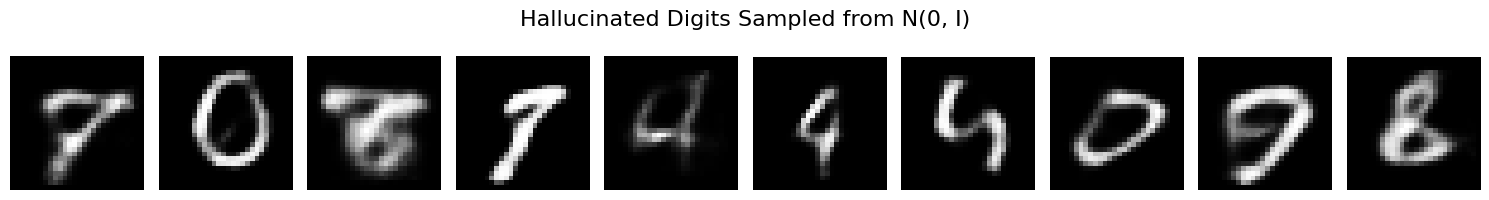

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from datasets import load_dataset
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

class VariationalAutoencoder(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        
        self.encoder_shared = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
        )
        
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid() # constrain outputs to [0, 1]
        )

    def encode(self, x):
        h = self.encoder_shared(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        batch_size = x.shape[0]
        x_flat = x.view(batch_size, -1)
        
        mu, logvar = self.encode(x_flat)
        z = self.reparameterize(mu, logvar)
        x_hat_flat = self.decoder(z)
        
        x_hat = x_hat_flat.view(batch_size, 1, 28, 28)
        
        return x_hat, mu, logvar

def elbo_loss(x_hat, x, mu, logvar):
    BCE = F.binary_cross_entropy(x_hat, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return BCE + KLD

hf_mnist = load_dataset("mnist")
to_tensor = transforms.ToTensor() 

def format_batch(batch):
    batch["image"] = [to_tensor(img) for img in batch["image"]]
    return batch

hf_mnist.set_transform(format_batch)

train_loader = DataLoader(dataset=hf_mnist["train"], batch_size=128, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae = VariationalAutoencoder(latent_dim=16).to(device)
optimizer = Adam(vae.parameters(), lr=1e-3)

num_epochs = 15

print("Constructing the Generative Universe...")
for epoch in range(num_epochs):
    vae.train()
    epoch_loss = 0
    
    for batch in train_loader:
        x = batch["image"].to(device)
        
        optimizer.zero_grad()
        x_hat, mu, logvar = vae(x)
        
        loss = elbo_loss(x_hat, x, mu, logvar)
        loss.backward()
        epoch_loss += loss.item()
        optimizer.step()
        
    avg_loss = epoch_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{num_epochs}] | Average ELBO Loss: {avg_loss:.4f}")

print("\nScaffolding removed. Hallucinating novel digits...")
vae.eval()

num_samples = 10

with torch.inference_mode():
    z_random = torch.randn(num_samples, 16).to(device)
    generated_flat = vae.decoder(z_random)
    generated_images = generated_flat.view(num_samples, 28, 28).cpu().numpy()

fig, axes = plt.subplots(1, num_samples, figsize=(15, 2))
for i in range(num_samples):
    axes[i].imshow(generated_images[i], cmap='gray')
    axes[i].axis('off')

plt.suptitle("Hallucinated Digits Sampled from N(0, I)", fontsize=16)
plt.tight_layout()
plt.show()